In [2]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Load dataset
df_retail = pd.read_csv("q3_retail_promotions.csv")

# Convert transaction_date to datetime
df_retail["transaction_date"] = pd.to_datetime(df_retail["transaction_date"])

# Extract date-based features
df_retail["year"] = df_retail["transaction_date"].dt.year
df_retail["month"] = df_retail["transaction_date"].dt.month
df_retail["day_of_week"] = df_retail["transaction_date"].dt.day_name()

# Create binary month-end feature
df_retail["is_month_end"] = (df_retail["transaction_date"].dt.day >= 25).astype(int)

# Display sample to confirm new columns
display(df_retail[["transaction_date", "year", "month", "day_of_week", "is_month_end"]].head())


,transaction_date,year,month,day_of_week,is_month_end
0,2022-01-01,2022,1,Saturday,0
1,2022-01-01,2022,1,Saturday,0
2,2022-01-02,2022,1,Sunday,0
3,2022-01-02,2022,1,Sunday,0
4,2022-01-03,2022,1,Monday,0


## Date Feature Engineering

From the `transaction_date` column, the following new features were created:

- **year**: the year of the transaction  
- **month**: the month of the transaction  
- **day_of_week**: the weekday name of the transaction  
- **is_month_end**: a binary feature set to 1 if the day of the month is 25 or later, otherwise 0  

The sample output above confirms that these new columns were added successfully.

In [3]:
##Temporal Train-Test Split

# Sort the data by transaction_date
df_retail = df_retail.sort_values("transaction_date").reset_index(drop=True)

# Find split index for 80% train and 20% test
split_index = int(len(df_retail) * 0.8)

# Temporal split
train_df = df_retail.iloc[:split_index].copy()
test_df = df_retail.iloc[split_index:].copy()

print("Training set shape:", train_df.shape)
print("Test set shape:", test_df.shape)

print("\nTraining date range:")
print(train_df["transaction_date"].min(), "to", train_df["transaction_date"].max())

print("\nTest date range:")
print(test_df["transaction_date"].min(), "to", test_df["transaction_date"].max())

Training set shape: (960, 13)
Test set shape: (240, 13)

Training date range:
2022-01-01 00:00:00 to 2024-06-11 00:00:00

Test date range:
2024-06-12 00:00:00 to 2024-12-31 00:00:00


## Why random split is inappropriate for time-ordered data

A random split is not suitable for time-based data because it can mix past and future records between training and testing sets.

This causes **data leakage**, where the model may learn patterns from future data that would not be available in a real prediction situation.

By using a **temporal split**, the model is trained only on older records and tested on more recent records. This better reflects how the model would perform in real-world forecasting or time-based prediction tasks.


In [4]:
# Drop raw date column
train_features = train_df.drop(columns=["transaction_date"])
test_features = test_df.drop(columns=["transaction_date"])

# Categorical columns
categorical_features = ["promotion_type", "location_type", "store_size", "day_of_week"]

# Numerical columns
numerical_features = [
    col for col in train_features.columns
    if col not in categorical_features
]

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numerical_features)
    ]
)

# Fit on training set only
X_train_processed = preprocessor.fit_transform(train_features)
X_test_processed = preprocessor.transform(test_features)

print("Processed training data shape:", X_train_processed.shape)
print("Processed test data shape:", X_test_processed.shape)

Processed training data shape: (960, 26)
Processed test data shape: (240, 26)


## Preprocessing Pipeline

A scikit-learn preprocessing pipeline was built using **ColumnTransformer**.

It applies:
- **One-hot encoding** to the categorical variables:
  - `promotion_type`
  - `location_type`
  - `store_size`
- **StandardScaler** to all numerical features

The preprocessing was **fit only on the training set** and then applied to both the training and test sets.

This is important because fitting on the full dataset would cause **data leakage**, meaning information from the test set could influence the transformation process.

In [5]:
## Model Training and Evaluation.

# Separate features and target
X_train = train_df.drop(columns=["items_sold", "transaction_date"])
X_test = test_df.drop(columns=["items_sold", "transaction_date"])

y_train = train_df["items_sold"]
y_test = test_df["items_sold"]

# Define categorical and numerical columns
categorical_features = ["promotion_type", "location_type", "store_size", "day_of_week"]

numerical_features = [
    col for col in X_train.columns
    if col not in categorical_features
]

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numerical_features)
    ]
)

In [6]:
## Train Linear Regression inside pipeline
from sklearn.linear_model import LinearRegression

lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [7]:
## Train Random Forest Regressor inside pipeline

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_estimators=200))
])

rf_pipeline.fit(X_train, y_train)

print("Random Forest Regressor trained successfully.")


Random Forest Regressor trained successfully.


In [8]:
## Evaluate both models using RMSE and MAE

# Predictions
lr_pred = lr_pipeline.predict(X_test)
rf_pred = rf_pipeline.predict(X_test)

# Linear Regression metrics
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_mae = mean_absolute_error(y_test, lr_pred)

# Random Forest metrics
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)

print("Linear Regression Performance")
print("RMSE:", round(lr_rmse, 4))
print("MAE: ", round(lr_mae, 4))

print("\nRandom Forest Regressor Performance")
print("RMSE:", round(rf_rmse, 4))
print("MAE: ", round(rf_mae, 4))

Linear Regression Performance
RMSE: 27.0745
MAE:  21.1008

Random Forest Regressor Performance
RMSE: 30.6259
MAE:  23.9707


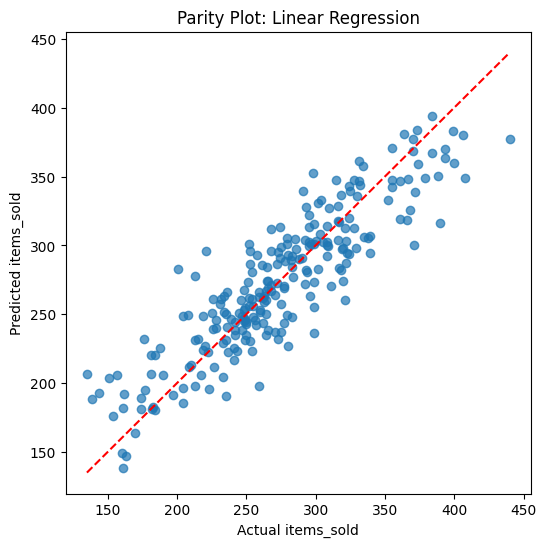

In [9]:
## Parity plot for Linear Regression

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(y_test, lr_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Parity Plot: Linear Regression")
plt.xlabel("Actual items_sold")
plt.ylabel("Predicted items_sold")
plt.show()


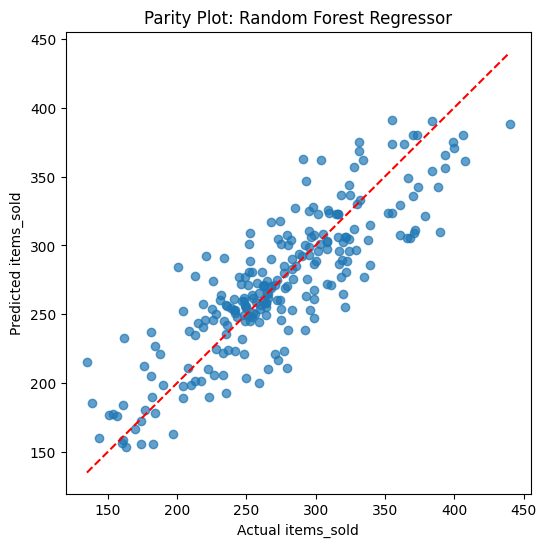

In [10]:
## Parity plot for Random Forest
plt.figure(figsize=(6, 6))
plt.scatter(y_test, rf_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Parity Plot: Random Forest Regressor")
plt.xlabel("Actual items_sold")
plt.ylabel("Predicted items_sold")
plt.show()

In [11]:
## Feature importances from Random Forest

# Get transformed feature names
ohe = rf_pipeline.named_steps["preprocessor"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(categorical_features)

all_feature_names = list(cat_feature_names) + numerical_features

# Get feature importances
importances = rf_pipeline.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print("Top 5 Most Influential Features:")
display(feature_importance_df.head(5))

Top 5 Most Influential Features:


,feature,importance
20,is_festival,0.176184
10,store_size_small,0.161809
19,is_weekend,0.125665
7,location_type_urban,0.112160
18,store_id,0.051923


## Model Evaluation Interpretation

Two regression models were trained to predict `items_sold`:

- **Linear Regression**
- **Random Forest Regressor**

Both models were built inside a scikit-learn pipeline so that preprocessing was applied correctly and consistently.

### Evaluation Metrics
The models were evaluated using:

- **RMSE (Root Mean Squared Error)**: shows the average prediction error with more penalty for larger errors
- **MAE (Mean Absolute Error)**: shows the average absolute difference between predicted and actual values

The model with the **lower RMSE and MAE** performs better.

### Parity Plots
The parity plots compare predicted values with actual values of `items_sold`.

- If points lie close to the diagonal line, predictions are accurate.
- If points are spread far from the line, prediction errors are higher.

### Feature Importance
The Random Forest model provides feature importance values, which show which variables contributed most to predicting `items_sold`.

The **top 5 features** printed above are the most influential variables in the Random Forest model.